# EDA — Análisis Exploratorio de Datos
## Proyecto: Antes de que se vayan — Deuna Churn Prediction

Este notebook analiza el dataset sintético de comerciantes de Deuna para:
- Entender la estructura y calidad de los datos
- Identificar patrones de abandono (churn)
- Descubrir qué variables tienen mayor poder predictivo
- Generar insights accionables para el equipo comercial

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Estilo visual consistente para todas las gráficas
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12

## 2. Carga del dataset

In [2]:
# Cargamos el CSV generado con los 2000 comerciantes de Ecuador
df = pd.read_csv('../data/deuna_merchants_ecuador.csv')

print(f'Filas: {df.shape[0]:,}')
print(f'Columnas: {df.shape[1]}')
df.head()

Filas: 2,000
Columnas: 28


,merchant_id,usuario,ciudad,tipo_negocio,cantidad_dinero_usd,latitud,longitud,meses_en_deuna,num_quejas,nivel_deuna,...,avg_ticket_last30,avg_ticket_last90,days_since_last_txn,active_days_last30,volume_trend,frequency_trend,consecutive_inactive_days,months_below_avg,peak_to_current_ratio,churned_next30
0,MER0001,Rosa Rodríguez,Guayaquil,Transporte,902.05,-2.151129,-79.863001,2,1,Bronce,...,161.19,108.94,16,10,-50.89,-22.98,9,0,0.69,0
1,MER0002,Sandra Medina,Quito,Servicios Profesionales,5028.79,-0.188568,-78.548422,10,1,Silver,...,170.02,168.40,1,20,-39.75,-9.88,0,1,0.46,0
2,MER0003,José Mora,Manta,Restaurante / Comida,4742.85,-0.997828,-80.758348,18,0,Silver,...,271.62,158.98,3,13,-3.23,-2.38,3,0,1.10,0
3,MER0004,Beatriz Chávez,Quito,Retail / Tienda,806.08,-0.215859,-78.542864,4,0,Bronce,...,57.14,30.28,8,10,-11.23,-16.30,7,1,0.77,0
4,MER0005,María Pérez,Cuenca,Salud / Farmacia,896.50,-2.944952,-79.028035,2,0,Bronce,...,127.53,50.49,14,11,-15.99,-7.44,9,1,0.68,0


## 3. Estructura y calidad de los datos

In [3]:
# Tipos de dato por columna — importante para saber qué necesita encoding antes del modelo
df.dtypes

merchant_id                   object
usuario                       object
ciudad                        object
tipo_negocio                  object
cantidad_dinero_usd          float64
latitud                      float64
longitud                     float64
meses_en_deuna                 int64
num_quejas                     int64
nivel_deuna                   object
tiene_tarjeta                  int64
tipo_tarjeta                  object
miembro_activo                 int64
edad                           int64
txn_count_last30               int64
txn_count_last90               int64
total_volume_last30          float64
total_volume_last90          float64
avg_ticket_last30            float64
avg_ticket_last90            float64
days_since_last_txn            int64
active_days_last30             int64
volume_trend                 float64
frequency_trend              float64
consecutive_inactive_days      int64
months_below_avg               int64
peak_to_current_ratio        float64
c

In [4]:
# Verificamos si hay valores nulos — un modelo no puede entrenarse con NaN sin tratar
nulos = df.isnull().sum()
print('Valores nulos por columna:')
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Sin valores nulos ✓')

Valores nulos por columna:
Sin valores nulos ✓


In [5]:
# Estadísticas descriptivas de las variables numéricas
# Nos ayuda a detectar outliers y rangos inesperados
df.describe().round(2)

,cantidad_dinero_usd,latitud,longitud,meses_en_deuna,num_quejas,tiene_tarjeta,miembro_activo,edad,txn_count_last30,txn_count_last90,...,avg_ticket_last30,avg_ticket_last90,days_since_last_txn,active_days_last30,volume_trend,frequency_trend,consecutive_inactive_days,months_below_avg,peak_to_current_ratio,churned_next30
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,...,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,2770.27,-1.46,-79.23,13.41,0.81,0.72,0.79,38.02,21.18,72.07,...,122.52,99.04,6.42,16.92,-12.55,-10.64,3.81,1.08,0.78,0.15
std,3723.94,1.28,0.72,12.54,1.19,0.45,0.41,9.70,20.03,63.20,...,79.80,53.58,8.04,5.03,16.33,13.68,5.16,1.13,0.19,0.36
min,2.45,-4.04,-80.76,1.00,0.00,0.00,0.00,20.00,0.00,9.00,...,5.00,5.00,0.00,2.00,-64.80,-56.47,0.00,0.00,0.11,0.00
25%,718.41,-2.23,-79.89,4.00,0.00,0.00,1.00,31.00,8.00,30.00,...,70.10,61.00,2.00,13.00,-23.66,-19.77,1.00,0.00,0.66,0.00
50%,1096.20,-1.25,-79.12,10.00,0.00,1.00,1.00,38.00,12.00,38.00,...,108.25,89.82,4.00,17.00,-12.41,-10.24,2.00,1.00,0.78,0.00
75%,3526.86,-0.25,-78.56,19.00,1.00,1.00,1.00,45.00,28.00,98.00,...,159.43,129.21,6.00,20.00,-1.39,-1.63,5.00,2.00,0.91,0.00
max,26408.01,1.00,-77.68,60.00,10.00,1.00,1.00,68.00,102.00,282.00,...,882.55,323.39,59.00,30.00,39.50,39.14,49.00,8.00,1.47,1.00


## 4. Análisis del target: churned_next30

Lo primero que debemos entender es cuántos comerciantes abandonan y si el dataset está desbalanceado.
Un dataset muy desbalanceado (ej. 95% no churn) requiere técnicas especiales como SMOTE o ajuste de pesos.

Distribución del target:
  Activos (0): 1,691 (84.5%)
  Churn   (1): 309 (15.4%)


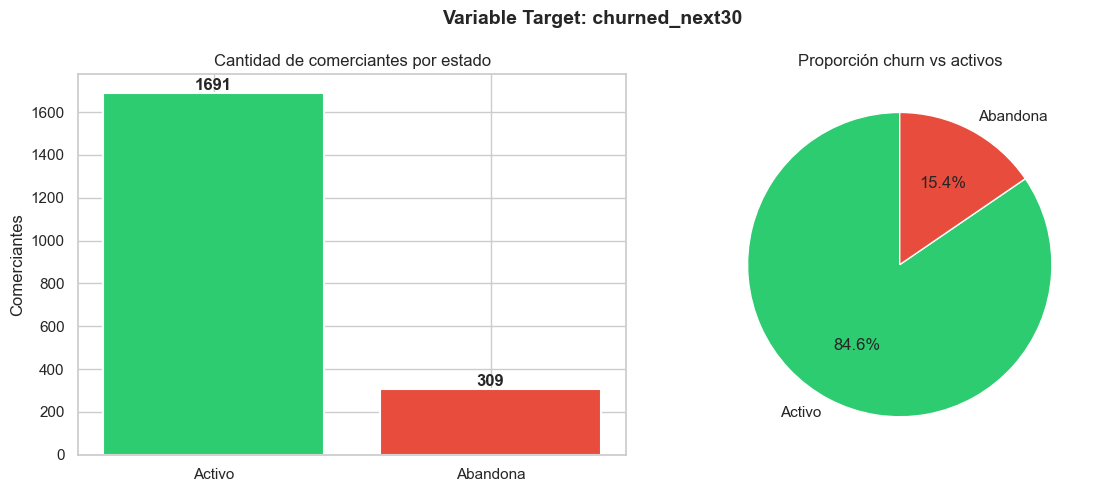

In [6]:
churn_counts = df['churned_next30'].value_counts()
churn_pct    = df['churned_next30'].value_counts(normalize=True) * 100

print('Distribución del target:')
print(f'  Activos (0): {churn_counts[0]:,} ({churn_pct[0]:.1f}%)')
print(f'  Churn   (1): {churn_counts[1]:,} ({churn_pct[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Gráfica de barras
axes[0].bar(['Activo', 'Abandona'], churn_counts.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Cantidad de comerciantes por estado')
axes[0].set_ylabel('Comerciantes')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfica de torta
axes[1].pie(churn_counts.values, labels=['Activo', 'Abandona'],
            colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción churn vs activos')

plt.suptitle('Variable Target: churned_next30', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Churn por variables categóricas

Analizamos qué segmentos tienen mayor tasa de abandono — esto es directamente accionable para el equipo comercial.

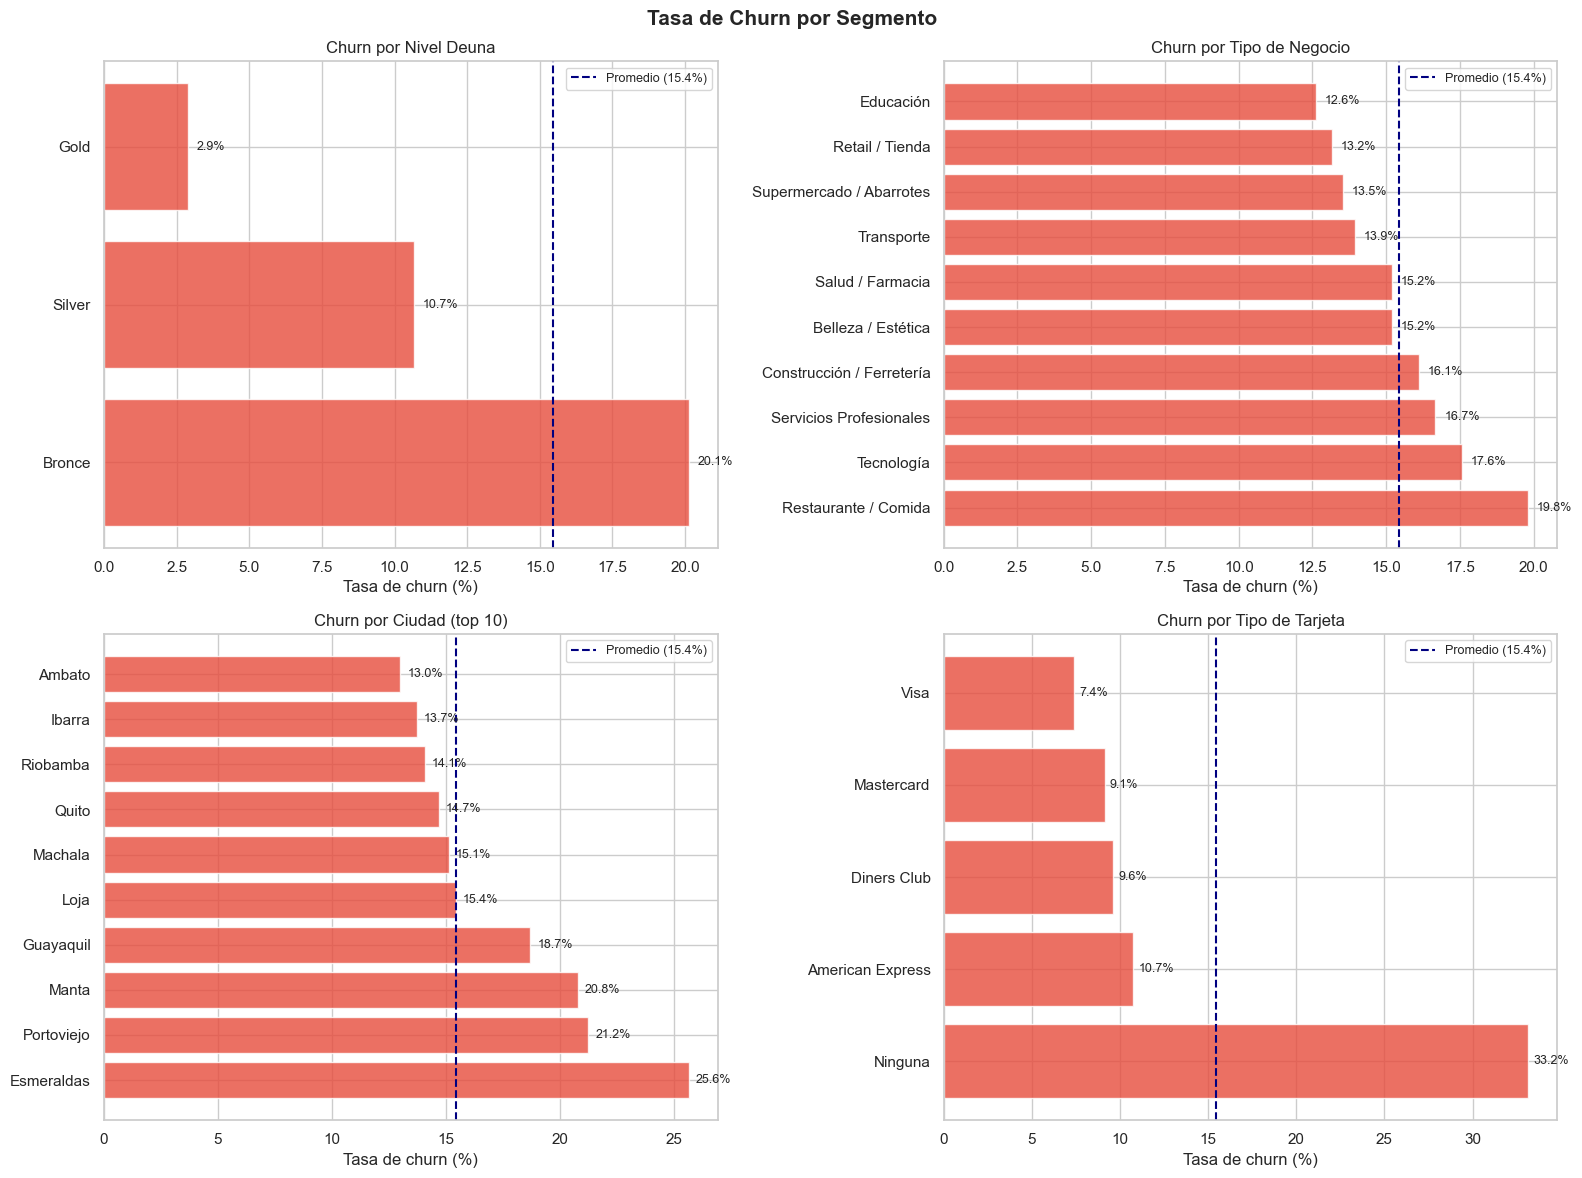

In [7]:
# Función reutilizable para calcular tasa de churn por categoría
def churn_rate_por_grupo(columna, titulo, ax, top_n=None):
    tasa = df.groupby(columna)['churned_next30'].mean().sort_values(ascending=False) * 100
    if top_n:
        tasa = tasa.head(top_n)
    bars = ax.barh(tasa.index, tasa.values, color='#e74c3c', alpha=0.8)
    ax.set_xlabel('Tasa de churn (%)')
    ax.set_title(titulo)
    ax.axvline(df['churned_next30'].mean() * 100, color='navy', linestyle='--',
               linewidth=1.5, label=f'Promedio ({df["churned_next30"].mean()*100:.1f}%)')
    ax.legend(fontsize=9)
    for bar, val in zip(bars, tasa.values):
        ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

churn_rate_por_grupo('nivel_deuna',  'Churn por Nivel Deuna',          axes[0, 0])
churn_rate_por_grupo('tipo_negocio', 'Churn por Tipo de Negocio',      axes[0, 1])
churn_rate_por_grupo('ciudad',       'Churn por Ciudad (top 10)',       axes[1, 0], top_n=10)
churn_rate_por_grupo('merchant_size' if 'merchant_size' in df.columns else 'tipo_tarjeta',
                     'Churn por Tipo de Tarjeta', axes[1, 1])

plt.suptitle('Tasa de Churn por Segmento', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Distribución de variables numéricas clave

Comparamos la distribución de cada variable entre comerciantes que abandonan y los que se quedan.
Si las distribuciones son distintas, la variable tiene poder predictivo.

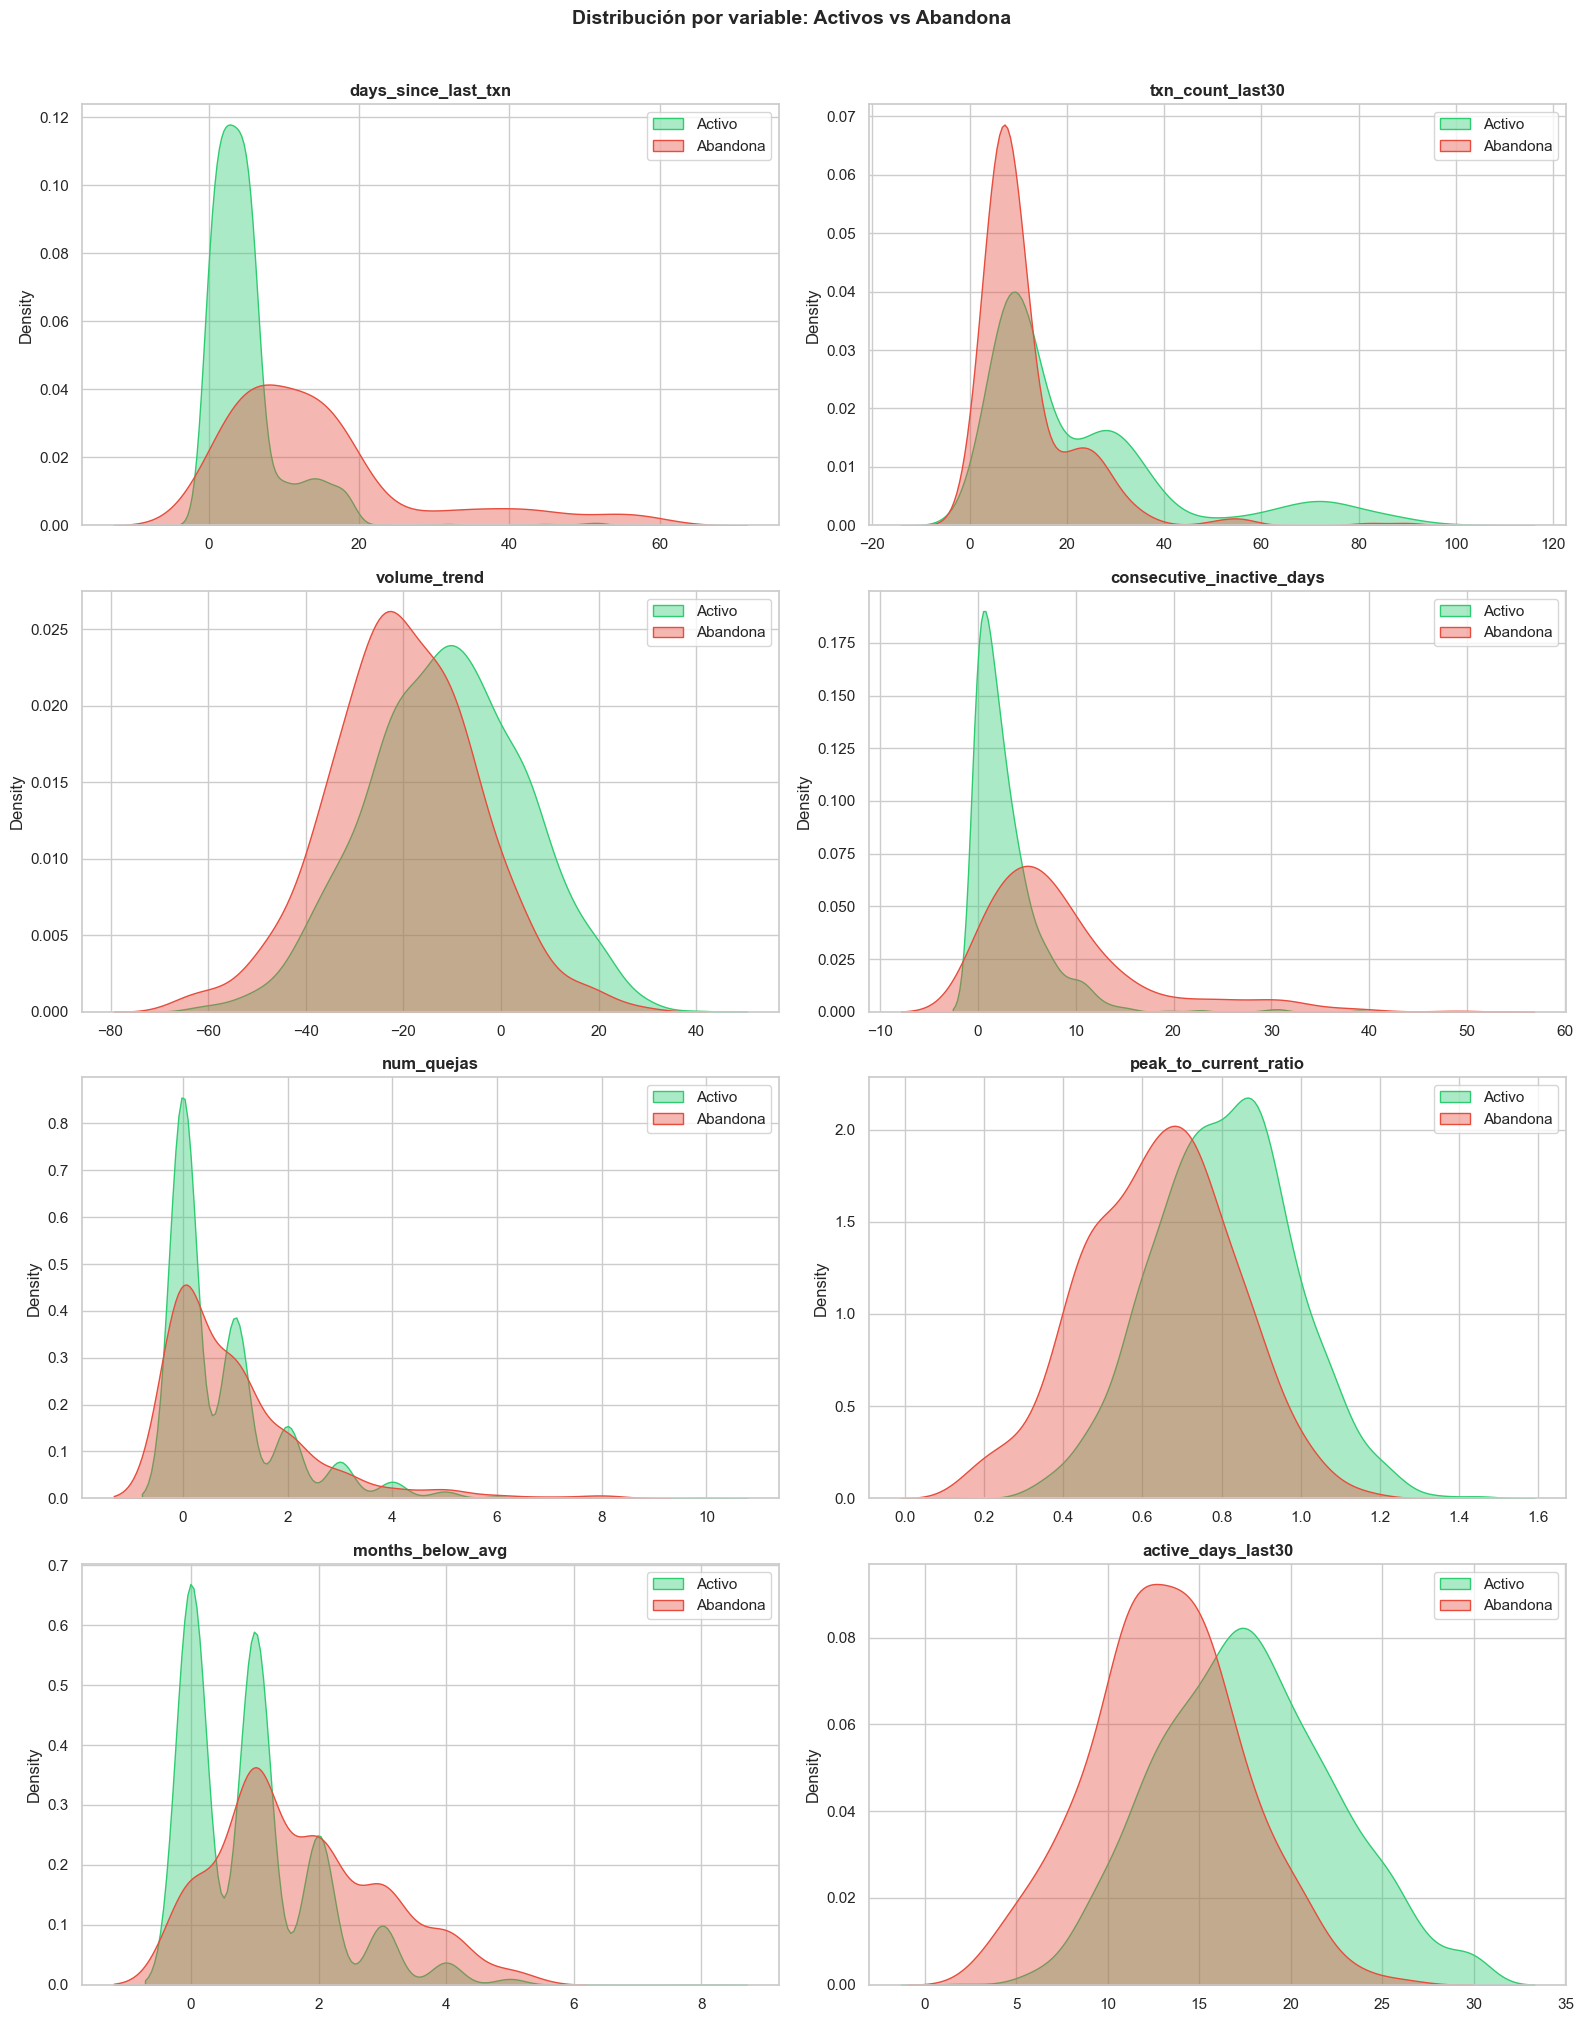

In [8]:
# Variables más relevantes para el churn según el diseño del dataset
vars_numericas = [
    'days_since_last_txn',
    'txn_count_last30',
    'volume_trend',
    'consecutive_inactive_days',
    'num_quejas',
    'peak_to_current_ratio',
    'months_below_avg',
    'active_days_last30',
]

fig, axes = plt.subplots(4, 2, figsize=(16, 20))
axes = axes.flatten()

for idx, var in enumerate(vars_numericas):
    # Superponemos la distribución de churn=0 y churn=1 para ver si se separan
    for churn_val, color, label in [(0, '#2ecc71', 'Activo'), (1, '#e74c3c', 'Abandona')]:
        sns.kdeplot(
            df[df['churned_next30'] == churn_val][var],
            ax=axes[idx], color=color, label=label, fill=True, alpha=0.4
        )
    axes[idx].set_title(var, fontweight='bold')
    axes[idx].legend()
    axes[idx].set_xlabel('')

plt.suptitle('Distribución por variable: Activos vs Abandona', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## 7. Matriz de correlación

Detectamos variables redundantes (correlación > 0.85 entre sí) que podrían afectar el modelo,
y vemos cuáles tienen mayor correlación con el target.

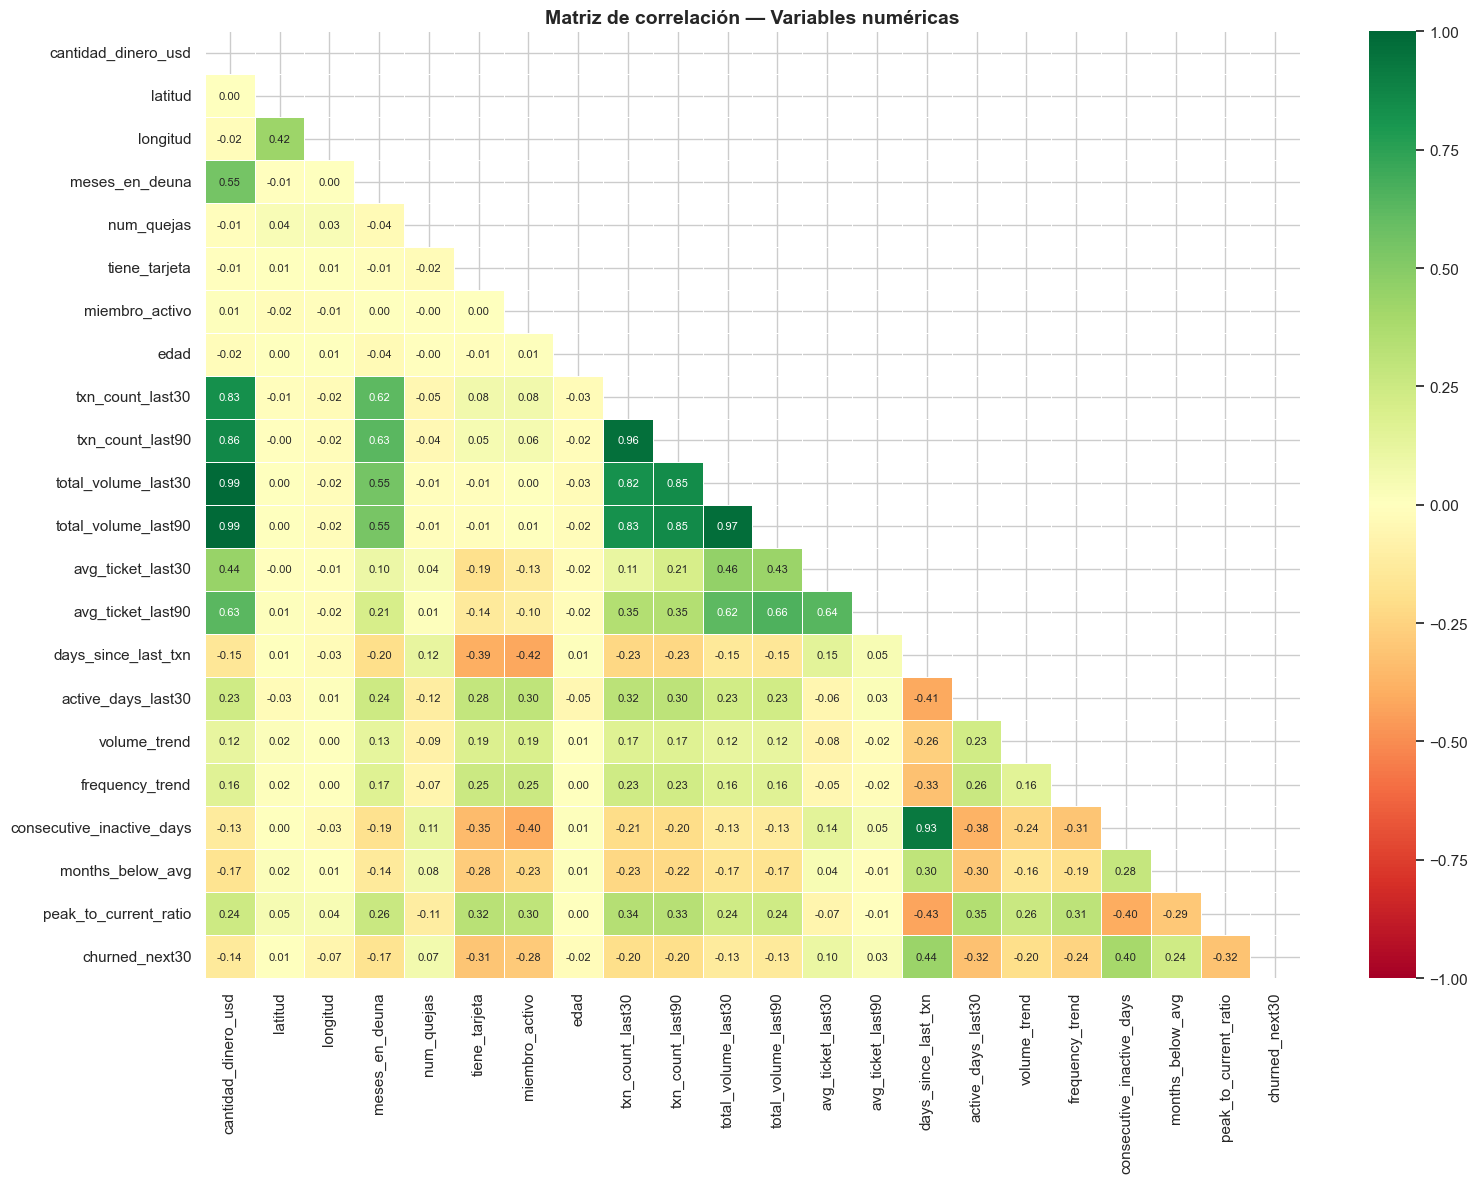

In [9]:
# Seleccionamos solo columnas numéricas para la correlación
cols_num = df.select_dtypes(include=np.number).columns.tolist()
cols_num = [c for c in cols_num if c != 'merchant_id']

corr = df[cols_num].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))  # Mostramos solo triángulo inferior
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 8}
)
plt.title('Matriz de correlación — Variables numéricas', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

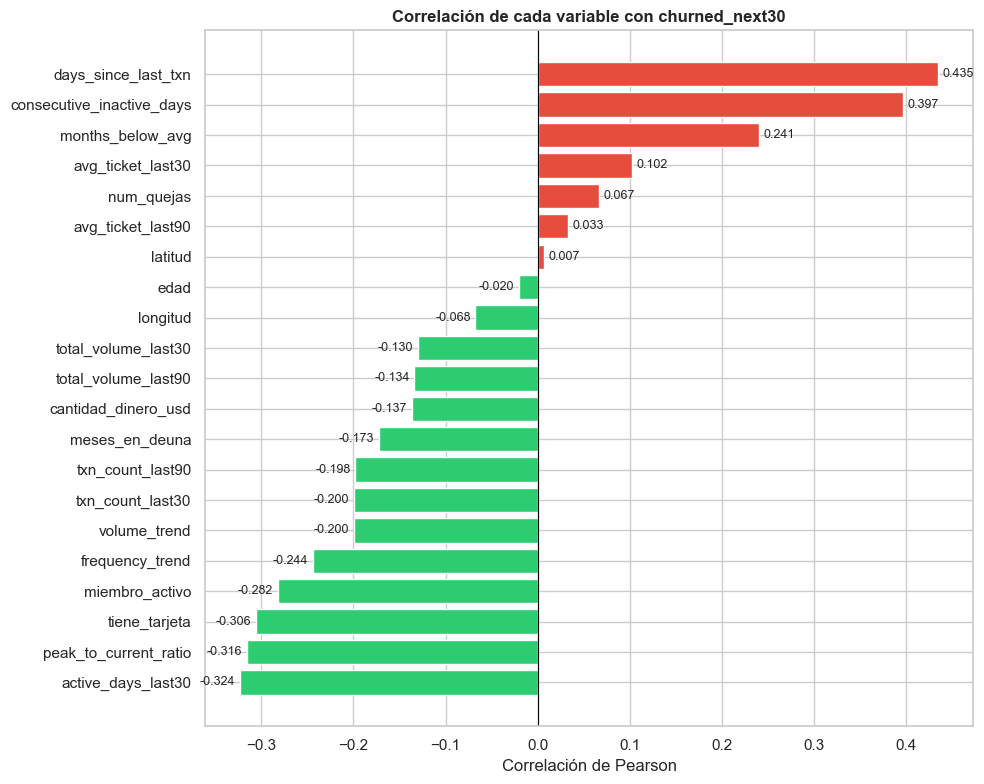

In [10]:
# Correlación directa de cada variable con el target — muestra el poder predictivo individual
corr_target = df[cols_num].corr()['churned_next30'].drop('churned_next30').sort_values()

colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in corr_target.values]

plt.figure(figsize=(10, 8))
bars = plt.barh(corr_target.index, corr_target.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Correlación de cada variable con churned_next30', fontweight='bold')
plt.xlabel('Correlación de Pearson')
for bar, val in zip(bars, corr_target.values):
    plt.text(val + (0.005 if val >= 0 else -0.005), bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)
plt.tight_layout()
plt.show()

## 8. Análisis de recencia (days_since_last_txn)

La recencia es el predictor más fuerte de churn en plataformas transaccionales.
Analizamos en qué umbral de días el riesgo de abandono se dispara.

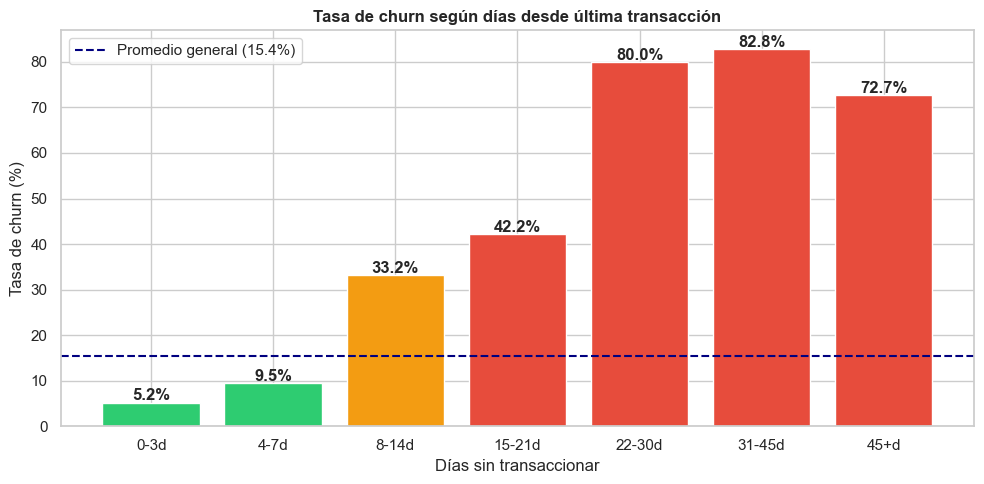

In [11]:
# Agrupamos por rangos de días para ver la tasa de churn en cada rango
bins   = [0, 3, 7, 14, 21, 30, 45, 100]
labels = ['0-3d', '4-7d', '8-14d', '15-21d', '22-30d', '31-45d', '45+d']

df['recencia_bucket'] = pd.cut(df['days_since_last_txn'], bins=bins, labels=labels)
churn_recencia = df.groupby('recencia_bucket', observed=True)['churned_next30'].mean() * 100

plt.figure(figsize=(10, 5))
bars = plt.bar(churn_recencia.index, churn_recencia.values,
               color=['#2ecc71' if v < 20 else '#f39c12' if v < 40 else '#e74c3c'
                      for v in churn_recencia.values])
plt.axhline(df['churned_next30'].mean() * 100, color='navy', linestyle='--',
            label=f'Promedio general ({df["churned_next30"].mean()*100:.1f}%)')
plt.title('Tasa de churn según días desde última transacción', fontweight='bold')
plt.xlabel('Días sin transaccionar')
plt.ylabel('Tasa de churn (%)')
plt.legend()
for bar, val in zip(bars, churn_recencia.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 0.5,
             f'{val:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

df.drop(columns=['recencia_bucket'], inplace=True)

## 9. Nivel Deuna vs Churn — análisis cruzado

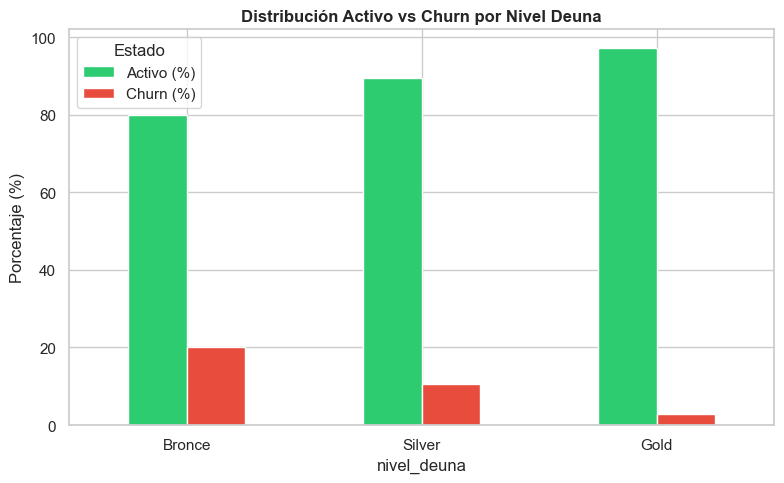

             Activo (%)  Churn (%)
nivel_deuna                       
Bronce             79.9       20.1
Silver             89.3       10.7
Gold               97.1        2.9


In [12]:
# Tabla cruzada: muestra cuántos comerciantes por nivel Deuna abandonan vs se quedan
tabla = pd.crosstab(df['nivel_deuna'], df['churned_next30'],
                    values=df['churned_next30'], aggfunc='count', normalize='index') * 100
tabla.columns = ['Activo (%)', 'Churn (%)']
tabla = tabla.reindex(['Bronce', 'Silver', 'Gold'])

tabla.plot(kind='bar', color=['#2ecc71', '#e74c3c'], edgecolor='white',
           figsize=(8, 5), rot=0)
plt.title('Distribución Activo vs Churn por Nivel Deuna', fontweight='bold')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Estado')
plt.tight_layout()
plt.show()

print(tabla.round(1))

## 10. Mapa de calor geográfico — Churn por ciudad

Tasa de churn por ciudad:
       ciudad  total  churners  tasa_churn
   Esmeraldas     39        10        25.6
   Portoviejo     80        17        21.2
        Manta    101        21        20.8
    Guayaquil    417        78        18.7
         Loja    123        19        15.4
      Machala    119        18        15.1
        Quito    538        79        14.7
     Riobamba     64         9        14.1
       Ibarra     51         7        13.7
       Ambato    100        13        13.0
     Babahoyo     31         4        12.9
Santo Domingo     93        12        12.9
       Cuenca    188        18         9.6
    Latacunga     41         3         7.3
       Tulcán     15         1         6.7


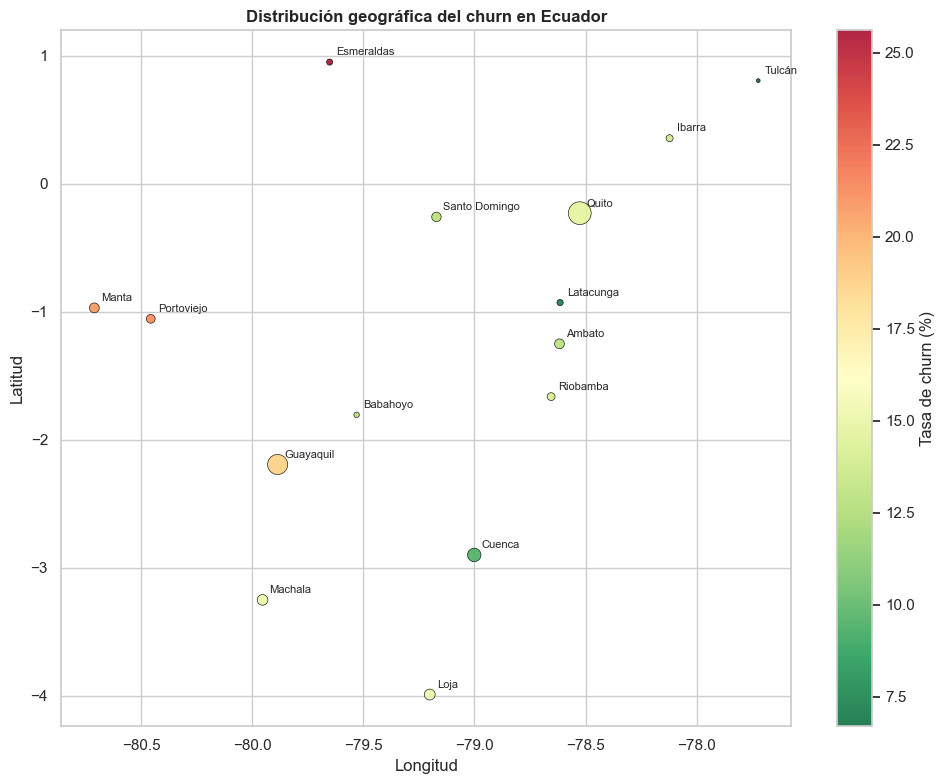

In [13]:
# Resumen de churn por ciudad: total, churners y tasa
geo_churn = df.groupby('ciudad').agg(
    total=('merchant_id', 'count'),
    churners=('churned_next30', 'sum'),
    lat=('latitud', 'mean'),
    lon=('longitud', 'mean')
).reset_index()
geo_churn['tasa_churn'] = (geo_churn['churners'] / geo_churn['total'] * 100).round(1)
geo_churn = geo_churn.sort_values('tasa_churn', ascending=False)

print('Tasa de churn por ciudad:')
print(geo_churn[['ciudad', 'total', 'churners', 'tasa_churn']].to_string(index=False))

# Scatter geográfico — tamaño del punto = total comercios, color = tasa de churn
plt.figure(figsize=(10, 8))
scatter = plt.scatter(
    geo_churn['lon'], geo_churn['lat'],
    s=geo_churn['total'] * 0.5,
    c=geo_churn['tasa_churn'],
    cmap='RdYlGn_r', alpha=0.85, edgecolors='black', linewidth=0.5
)
plt.colorbar(scatter, label='Tasa de churn (%)')
for _, row in geo_churn.iterrows():
    plt.annotate(row['ciudad'], (row['lon'], row['lat']),
                 textcoords='offset points', xytext=(5, 5), fontsize=8)
plt.title('Distribución geográfica del churn en Ecuador', fontweight='bold')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.tight_layout()
plt.show()

## 11. Análisis de quejas vs churn

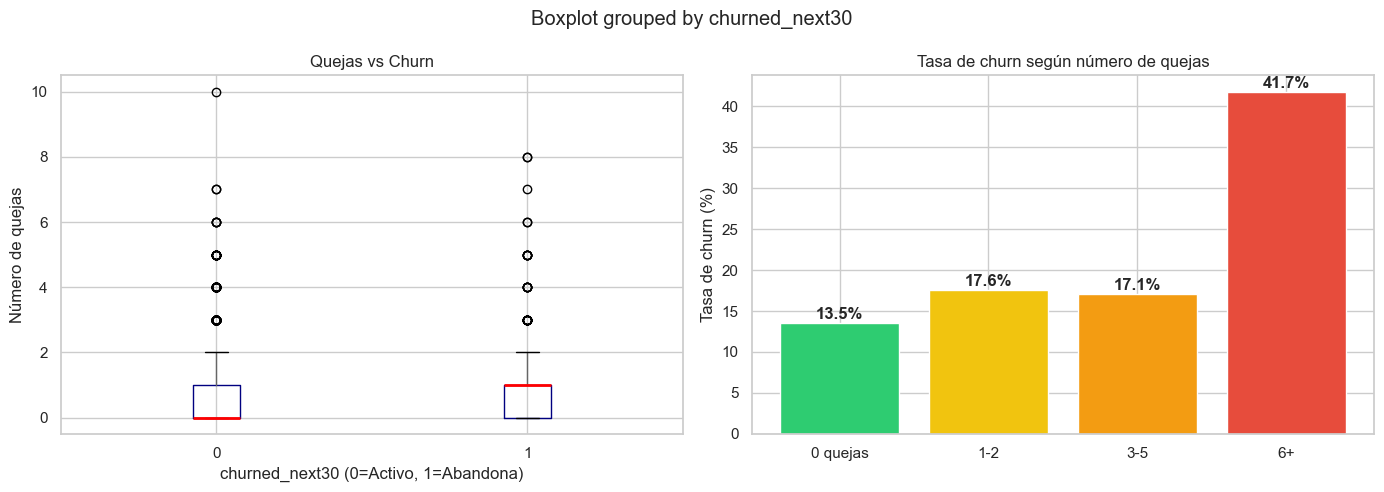

In [14]:
# Boxplot: ¿los comerciantes que abandonan tienen más quejas?
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot de quejas por estado
df.boxplot(column='num_quejas', by='churned_next30', ax=axes[0],
           boxprops=dict(color='navy'), medianprops=dict(color='red', linewidth=2))
axes[0].set_title('Distribución de quejas por estado')
axes[0].set_xlabel('churned_next30 (0=Activo, 1=Abandona)')
axes[0].set_ylabel('Número de quejas')
plt.sca(axes[0])
plt.title('Quejas vs Churn')

# Tasa de churn por número de quejas (agrupado)
df['quejas_bucket'] = pd.cut(df['num_quejas'], bins=[-1, 0, 2, 5, 15],
                              labels=['0 quejas', '1-2', '3-5', '6+'])
churn_quejas = df.groupby('quejas_bucket', observed=True)['churned_next30'].mean() * 100
axes[1].bar(churn_quejas.index, churn_quejas.values,
            color=['#2ecc71', '#f1c40f', '#f39c12', '#e74c3c'])
axes[1].set_title('Tasa de churn según número de quejas')
axes[1].set_ylabel('Tasa de churn (%)')
for i, v in enumerate(churn_quejas.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

df.drop(columns=['quejas_bucket'], inplace=True)

## 12. Resumen de hallazgos del EDA

Este resumen será la base del **documento de análisis** para el jurado.

In [15]:
tasa_global   = df['churned_next30'].mean() * 100
top_ciudad    = geo_churn.iloc[0]
churn_bronce  = df[df['nivel_deuna'] == 'Bronce']['churned_next30'].mean() * 100
churn_gold    = df[df['nivel_deuna'] == 'Gold']['churned_next30'].mean() * 100
median_dias_churn    = df[df['churned_next30'] == 1]['days_since_last_txn'].median()
median_dias_activo   = df[df['churned_next30'] == 0]['days_since_last_txn'].median()

print('=' * 55)
print('       RESUMEN DE HALLAZGOS — EDA')
print('=' * 55)
print(f'  Tasa global de churn:          {tasa_global:.1f}%')
print(f'  Churn en nivel Bronce:         {churn_bronce:.1f}%')
print(f'  Churn en nivel Gold:           {churn_gold:.1f}%')
print(f'  Ciudad con más churn:          {top_ciudad["ciudad"]} ({top_ciudad["tasa_churn"]}%)')
print(f'  Días sin transaccionar (churn):  {median_dias_churn:.0f} días (mediana)')
print(f'  Días sin transaccionar (activo): {median_dias_activo:.0f} días (mediana)')
print('=' * 55)
print()
print('Top 5 variables con mayor correlación con churn:')
top5 = df[cols_num].corr()['churned_next30'].drop('churned_next30').abs().sort_values(ascending=False).head(5)
for var, val in top5.items():
    print(f'  {var:<35} {val:.3f}')

       RESUMEN DE HALLAZGOS — EDA
  Tasa global de churn:          15.4%
  Churn en nivel Bronce:         20.1%
  Churn en nivel Gold:           2.9%
  Ciudad con más churn:          Esmeraldas (25.6%)
  Días sin transaccionar (churn):  12 días (mediana)
  Días sin transaccionar (activo): 4 días (mediana)

Top 5 variables con mayor correlación con churn:
  days_since_last_txn                 0.435
  consecutive_inactive_days           0.397
  active_days_last30                  0.324
  peak_to_current_ratio               0.316
  tiene_tarjeta                       0.306
